# Autoregressive processes, visually

An **AR($p$)** process makes the present a noisy linear function of its previous $p$ values:

$$
x_t=c+\phi_1x_{t-1}+\cdots+\phi_px_{t-p}+\varepsilon_t,
\qquad \varepsilon_t\overset{\mathrm{iid}}{\sim}(0,\sigma_\varepsilon^2).
$$

This notebook turns the compact cheatsheet definition into pictures. We will connect coefficients, trajectories, autocorrelation, impulse responses, and the roots of

$$
\phi(z)=1-\phi_1z-\cdots-\phi_pz^p.
$$

### Learning goals

- Recognize persistence, mean reversion, alternation, oscillation, unit roots, and explosion.
- Understand why $|\phi_1|<1$ is the AR(1) stationarity condition.
- Apply the root-outside-the-unit-circle condition to AR(2) and AR(3).
- Distinguish the intercept $c$ from the unconditional mean.
- Read the ACF and impulse response implied by an AR model.

## 1. The model and the backshift operator

The backshift operator satisfies $Bx_t=x_{t-1}$, so

$$
\underbrace{(1-\phi_1B-\cdots-\phi_pB^p)}_{\phi(B)}x_t=c+\varepsilon_t.
$$

White noise supplies new, unpredictable information. The AR coefficients determine how previous shocks propagate into the future. For a stationary AR($p$), taking expectations gives

$$
\mu=E[x_t]=c+\left(\sum_{i=1}^{p}\phi_i\right)\mu
\quad\Longrightarrow\quad
\mu=\frac{c}{1-\sum_{i=1}^{p}\phi_i}.
$$

Stationarity is not “a flat-looking line.” It means that the probabilistic behavior is invariant with absolute time. A stationary realization can still contain long runs and oscillations.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
from matplotlib.patches import Circle
from matplotlib.ticker import FuncFormatter
import numpy as np
import polars as pl

TOOLS_DIR = Path("../tools").resolve()
if not TOOLS_DIR.exists():
    TOOLS_DIR = Path("Data/DataScience/Models/TimeSeries/tools").resolve()
sys.path.insert(0, str(TOOLS_DIR))
from numpy_stattools import acf

SEED = 20260807
COLORS = {
    "navy": "#173F5F",
    "blue": "#3B73B9",
    "teal": "#00879A",
    "green": "#49A66D",
    "orange": "#E07A3F",
    "red": "#D1495B",
    "purple": "#7B61A8",
    "gray": "#7B8794",
    "light": "#D9E2EC",
}

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update(
    {
        "figure.dpi": 120,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.titleweight": "bold",
        "axes.labelcolor": "#243B53",
        "text.color": "#243B53",
        "font.size": 10,
    }
)
pl.Config.set_tbl_cols(12)

polars.config.Config

In [2]:
def ar_roots(phi) -> np.ndarray:
    """Roots of 1 - phi_1 z - ... - phi_p z^p."""
    coefficients = np.asarray(phi, dtype=float)
    if coefficients.ndim != 1 or coefficients.size == 0:
        raise ValueError("phi must be a non-empty one-dimensional sequence")
    if np.all(coefficients == 0):
        return np.array([], dtype=complex)
    polynomial = np.r_[-coefficients[::-1], 1.0]
    first_nonzero = np.flatnonzero(polynomial != 0)[0]
    return np.roots(polynomial[first_nonzero:])


def is_stationary(phi, tolerance: float = 1e-10) -> bool:
    roots = ar_roots(phi)
    return roots.size == 0 or bool(np.all(np.abs(roots) > 1.0 + tolerance))


def unconditional_mean(phi, c: float = 0.0) -> float:
    if not is_stationary(phi):
        return np.nan
    return c / (1.0 - np.sum(phi))


def simulate_ar(
    phi,
    *,
    n: int = 240,
    c: float = 0.0,
    sigma: float = 1.0,
    burnin: int = 500,
    seed: int = SEED,
) -> np.ndarray:
    """Simulate x_t = c + sum(phi_i x_{t-i}) + epsilon_t."""
    phi = np.asarray(phi, dtype=float)
    order = phi.size
    effective_burnin = burnin if is_stationary(phi) else 0
    total = n + effective_burnin + order
    rng = np.random.default_rng(seed)
    innovations = rng.normal(0.0, sigma, total)
    values = np.zeros(total)
    mean = unconditional_mean(phi, c)
    if np.isfinite(mean):
        values[:order] = mean
    for time in range(order, total):
        previous = values[time - order : time][::-1]
        values[time] = c + np.dot(phi, previous) + innovations[time]
    return values[order + effective_burnin :]


def impulse_response(phi, horizon: int = 40) -> np.ndarray:
    """Response psi_h to a one-unit innovation at h=0."""
    phi = np.asarray(phi, dtype=float)
    response = np.zeros(horizon)
    response[0] = 1.0
    for h in range(1, horizon):
        response[h] = sum(
            phi[lag - 1] * response[h - lag]
            for lag in range(1, min(phi.size, h) + 1)
        )
    return response


def root_label(phi) -> str:
    roots = ar_roots(phi)
    if roots.size == 0:
        return "no finite roots"
    return ", ".join(f"{root:.2f}" for root in roots)


def plot_root_plane(ax, phi, title: str) -> None:
    roots = ar_roots(phi)
    ax.add_patch(Circle((0, 0), 1, fill=False, color=COLORS["red"], linewidth=2))
    if roots.size:
        ax.scatter(roots.real, roots.imag, marker="x", s=85, linewidth=2.4, color=COLORS["navy"])
    limit = max(1.5, *(np.abs(roots) + 0.3)) if roots.size else 1.5
    limit = min(float(limit), 4.5)
    ax.axhline(0, color=COLORS["gray"], linewidth=0.8)
    ax.axvline(0, color=COLORS["gray"], linewidth=0.8)
    ax.set(xlim=(-limit, limit), ylim=(-limit, limit), aspect="equal", title=title)
    ax.set_xlabel("Real")
    ax.set_ylabel("Imaginary")

## 2. AR(1): one coefficient, many behaviors

For

$$x_t=c+\phi x_{t-1}+\varepsilon_t,$$

the sign of $\phi$ controls direction and its magnitude controls memory:

- $\phi=0$: white noise; the past is irrelevant.
- $0<\phi<1$: positive persistence.
- $-1<\phi<0$: alternating mean reversion.
- $|\phi|\approx1$: shocks decay very slowly.
- $|\phi|=1$: unit-root boundary.
- $|\phi|>1$: shocks grow rather than decay.

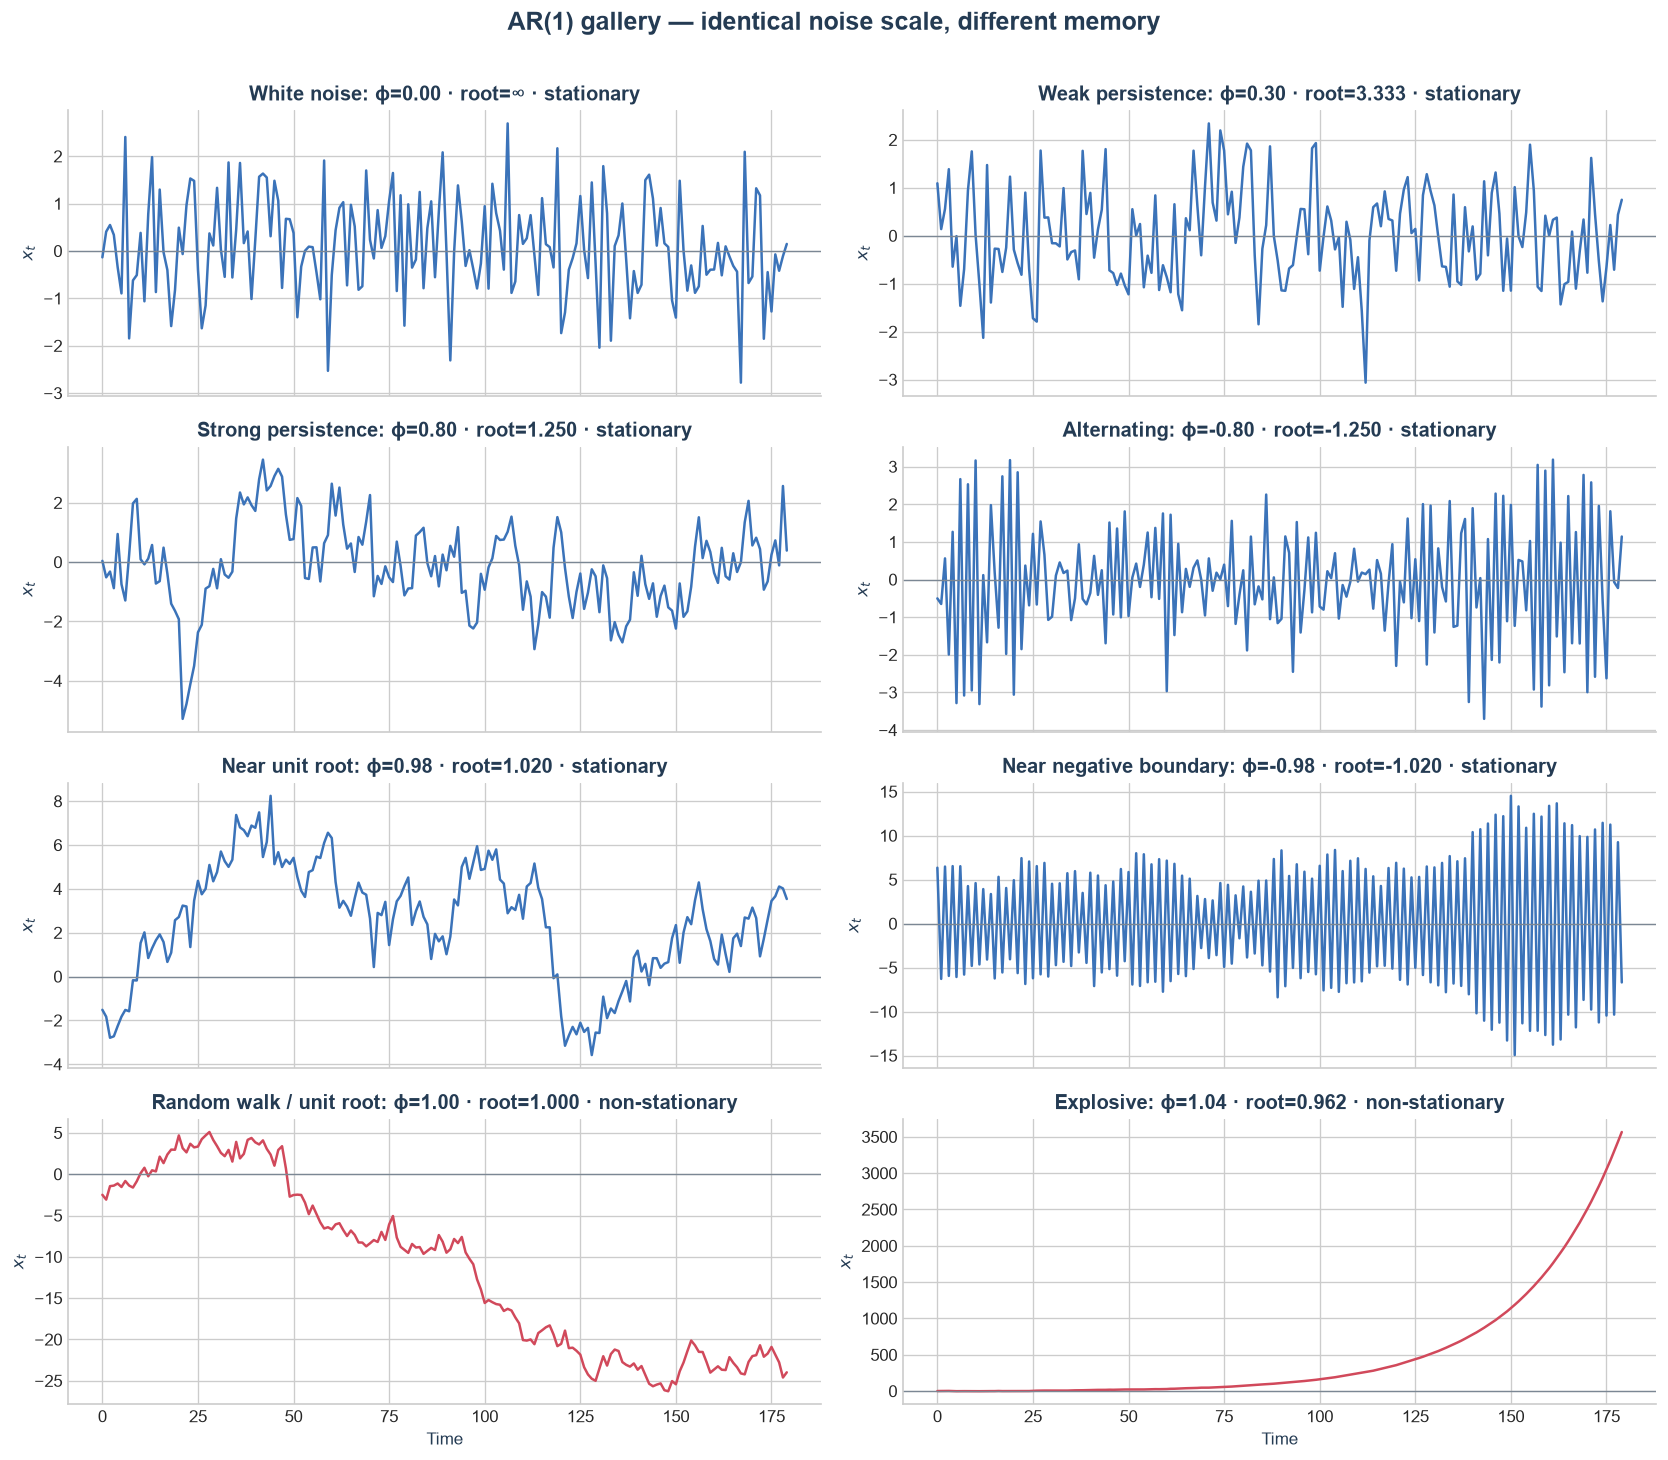

In [3]:
ar1_examples = [
    ("White noise", 0.00),
    ("Weak persistence", 0.30),
    ("Strong persistence", 0.80),
    ("Alternating", -0.80),
    ("Near unit root", 0.98),
    ("Near negative boundary", -0.98),
    ("Random walk / unit root", 1.00),
    ("Explosive", 1.04),
]

fig, axes = plt.subplots(4, 2, figsize=(14, 12), sharex=True)
for index, (axis, (label, phi)) in enumerate(zip(axes.flat, ar1_examples)):
    values = simulate_ar([phi], n=180, seed=SEED + index)
    color = COLORS["blue"] if abs(phi) < 1 else COLORS["red"]
    axis.plot(values, color=color, linewidth=1.5)
    axis.axhline(0, color=COLORS["gray"], linewidth=0.8)
    status = "stationary" if is_stationary([phi]) else "non-stationary"
    root = "∞" if phi == 0 else f"{1 / phi:.3f}"
    axis.set_title(f"{label}: ϕ={phi:.2f} · root={root} · {status}")
    axis.set_ylabel("$x_t$")
axes[-1, 0].set_xlabel("Time")
axes[-1, 1].set_xlabel("Time")
fig.suptitle("AR(1) gallery — identical noise scale, different memory", y=1.01, fontsize=15, fontweight="bold")
fig.tight_layout()
plt.show()

The stationary examples keep returning to the same distribution even when a realization wanders temporarily. The random walk does not return to a fixed level: every shock permanently changes its future path. The explosive process magnifies shocks.

Negative $\phi$ does **not** mean negative observations. It means that a positive deviation tends to be followed by a negative deviation, and vice versa.

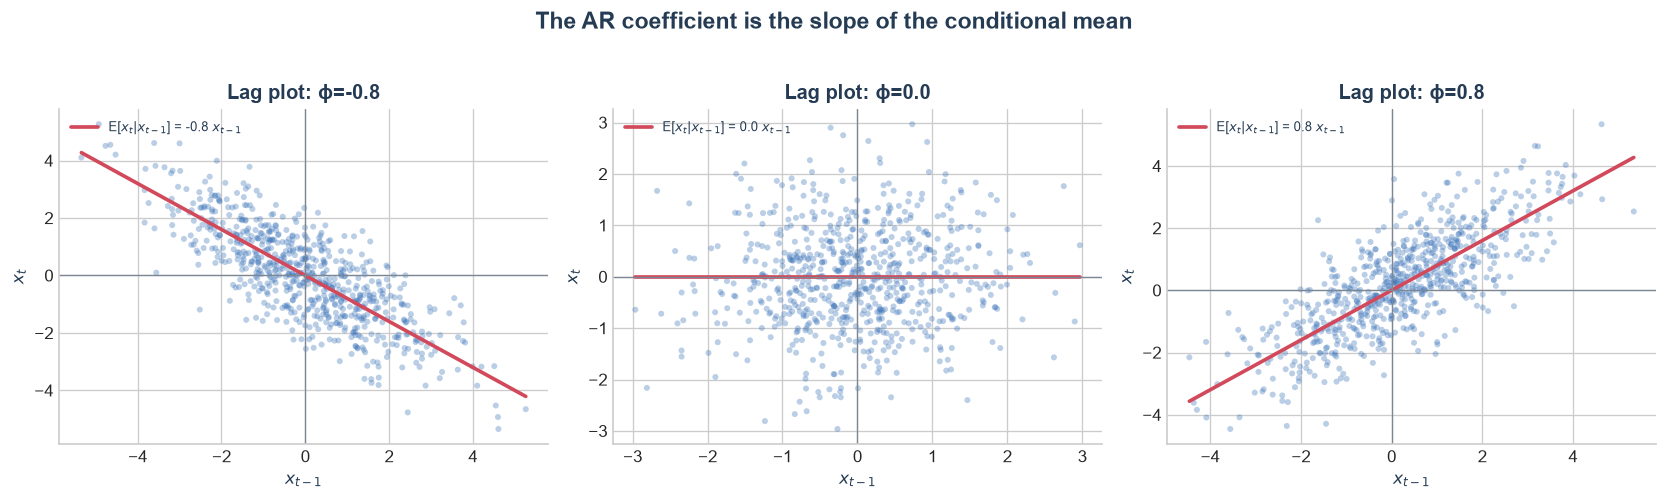

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for index, (axis, phi) in enumerate(zip(axes, [-0.8, 0.0, 0.8])):
    values = simulate_ar([phi], n=700, seed=SEED + 20 + index)
    previous, current = values[:-1], values[1:]
    axis.scatter(previous, current, s=13, alpha=0.35, color=COLORS["blue"], edgecolor="none")
    grid = np.linspace(previous.min(), previous.max(), 100)
    axis.plot(grid, phi * grid, color=COLORS["red"], linewidth=2.2, label=f"E[$x_t|x_{{t-1}}$] = {phi} $x_{{t-1}}$")
    axis.axhline(0, color=COLORS["gray"], linewidth=0.8)
    axis.axvline(0, color=COLORS["gray"], linewidth=0.8)
    axis.set(title=f"Lag plot: ϕ={phi}", xlabel="$x_{t-1}$", ylabel="$x_t$")
    axis.legend(loc="upper left", fontsize=8)
fig.suptitle("The AR coefficient is the slope of the conditional mean", y=1.03, fontsize=14, fontweight="bold")
fig.tight_layout()
plt.show()

### AR(1) autocorrelation

For a stationary AR(1), the autocorrelation has a closed form:

$$
\rho_k=\phi^k.
$$

Positive $\phi$ produces a smooth geometric decay. Negative $\phi$ produces a decay that alternates sign. Near the unit-root boundary, the ACF decays so slowly that a short sample can look non-stationary.

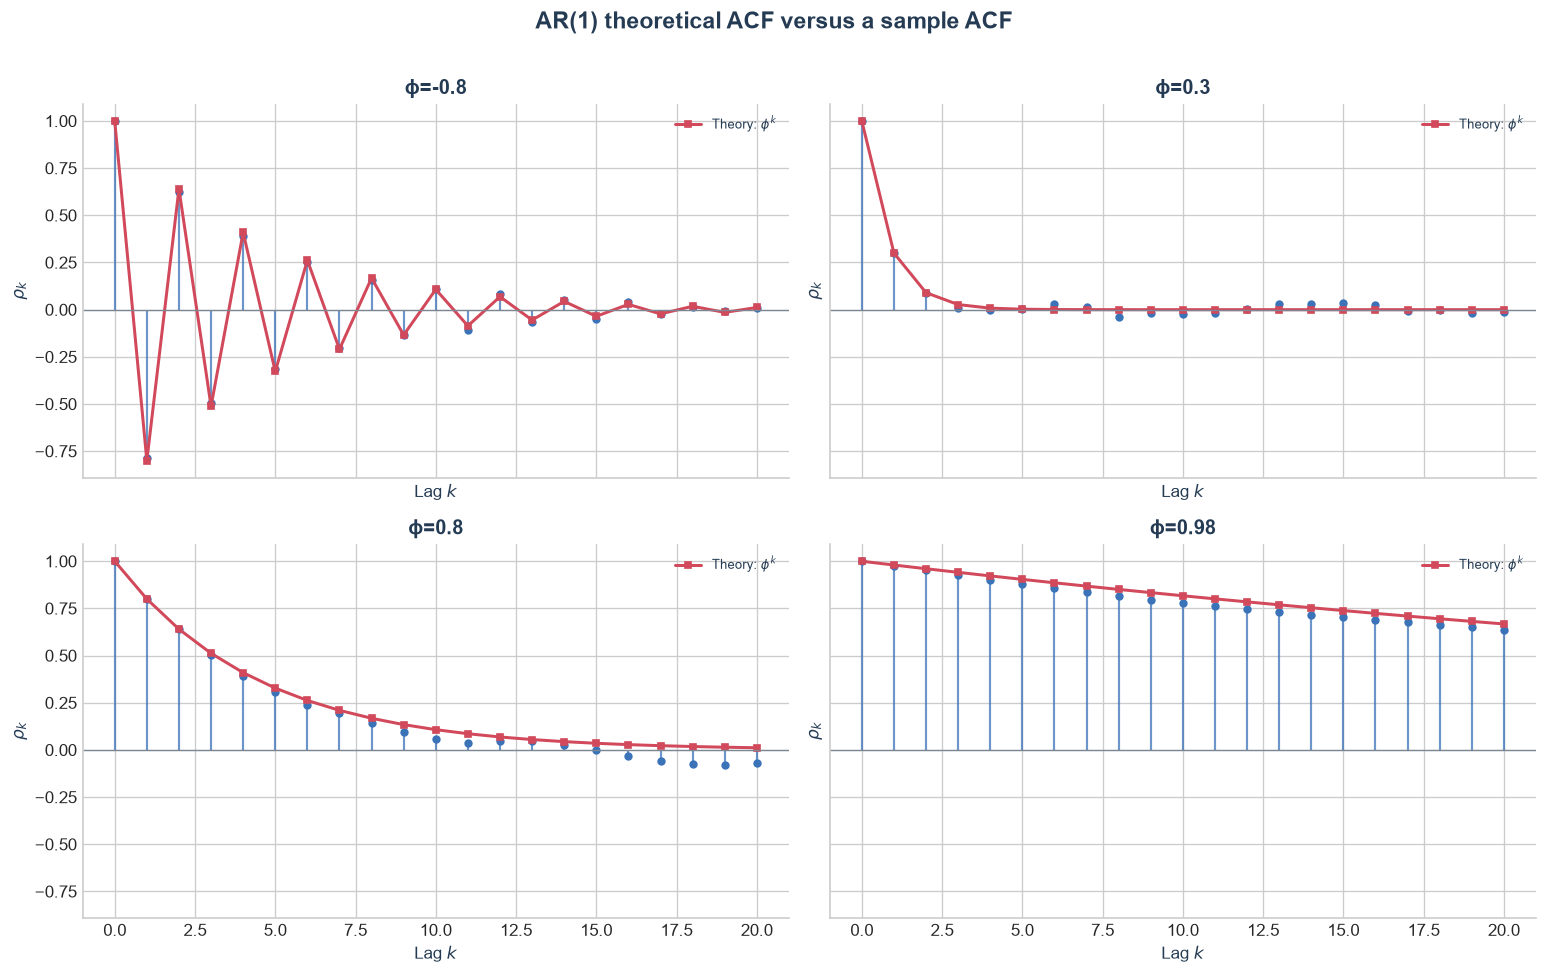

In [5]:
acf_phis = [-0.8, 0.3, 0.8, 0.98]
lags = np.arange(21)
fig, axes = plt.subplots(2, 2, figsize=(13, 8), sharex=True, sharey=True)
for index, (axis, phi) in enumerate(zip(axes.flat, acf_phis)):
    values = simulate_ar([phi], n=2_000, seed=SEED + 40 + index)
    sample = acf(values, nlags=20, fft=True)
    theoretical = phi**lags
    markerline, stemlines, _ = axis.stem(lags, sample, linefmt=COLORS["blue"], markerfmt="o", basefmt=" ")
    plt.setp(stemlines, linewidth=1.3, alpha=0.75)
    plt.setp(markerline, markersize=4, color=COLORS["blue"])
    axis.plot(lags, theoretical, color=COLORS["red"], marker="s", markersize=3.5, linewidth=1.8, label=r"Theory: $\phi^k$")
    axis.axhline(0, color=COLORS["gray"], linewidth=0.8)
    axis.set(title=f"ϕ={phi}", xlabel="Lag $k$", ylabel=r"$\rho_k$")
    axis.legend(fontsize=8)
fig.suptitle("AR(1) theoretical ACF versus a sample ACF", y=1.01, fontsize=14, fontweight="bold")
fig.tight_layout()
plt.show()

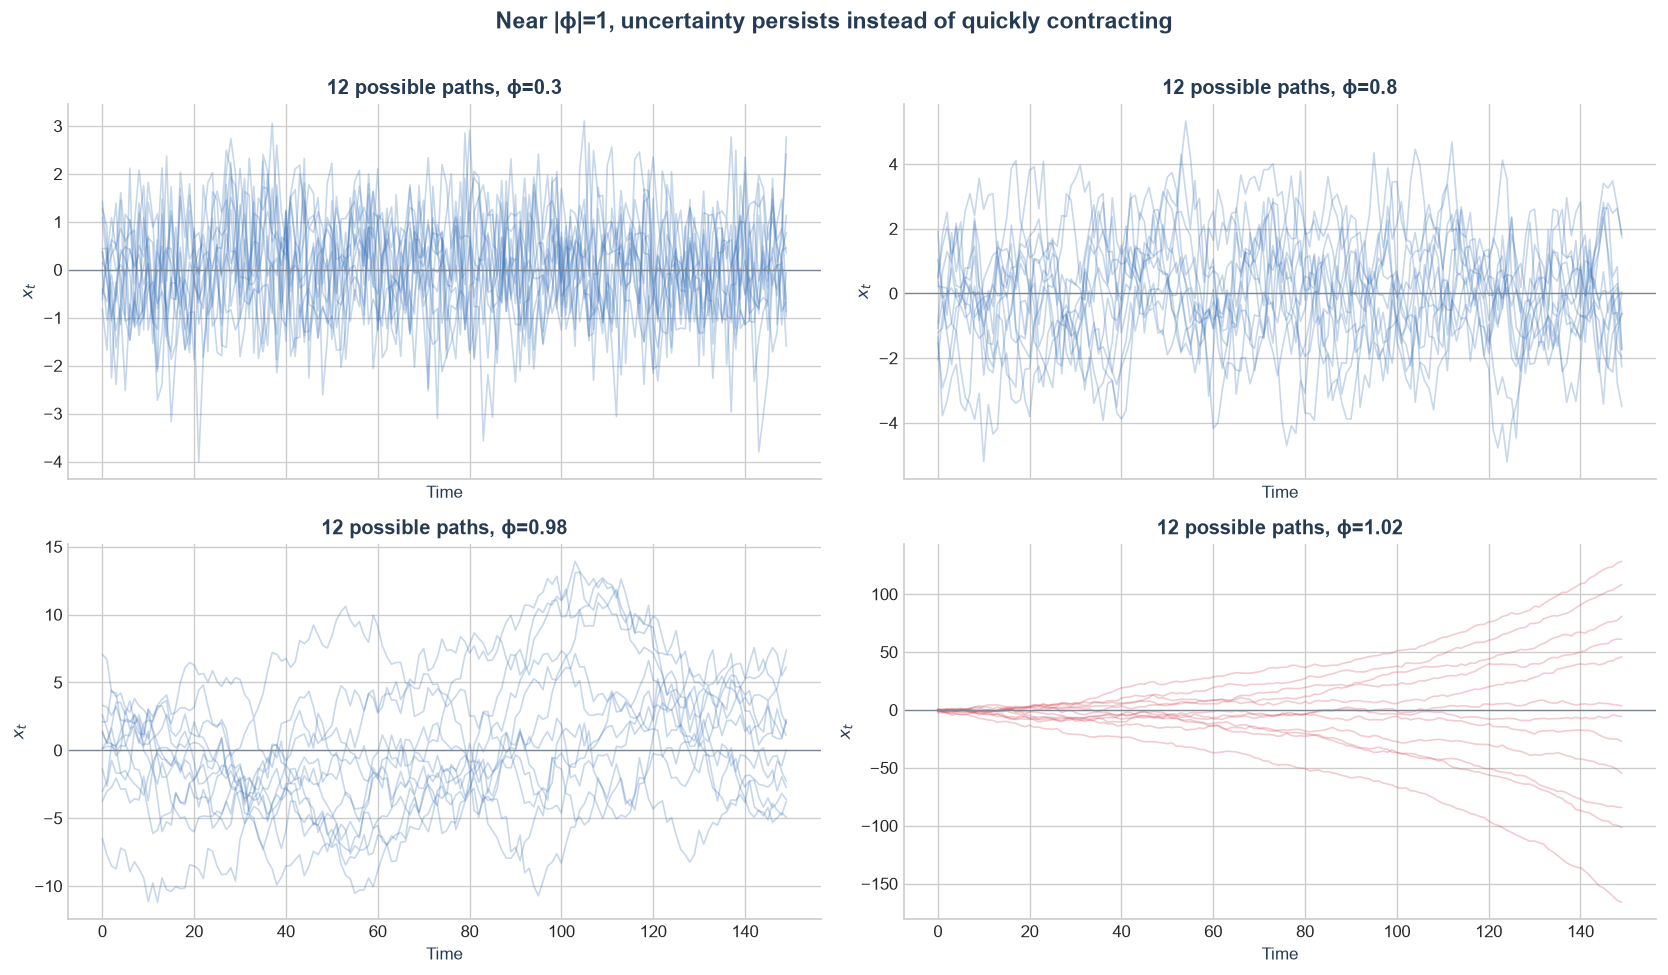

In [6]:
boundary_phis = [0.30, 0.80, 0.98, 1.02]
fig, axes = plt.subplots(2, 2, figsize=(14, 8), sharex=True)
for panel, (axis, phi) in enumerate(zip(axes.flat, boundary_phis)):
    for path in range(12):
        values = simulate_ar([phi], n=150, seed=SEED + 100 * panel + path)
        axis.plot(values, color=COLORS["blue"] if abs(phi) < 1 else COLORS["red"], alpha=0.28, linewidth=1)
    axis.axhline(0, color=COLORS["gray"], linewidth=0.8)
    axis.set(title=f"12 possible paths, ϕ={phi}", xlabel="Time", ylabel="$x_t$")
fig.suptitle("Near |ϕ|=1, uncertainty persists instead of quickly contracting", y=1.01, fontsize=14, fontweight="bold")
fig.tight_layout()
plt.show()

## 3. Why roots outside the unit circle?

For AR(1),

$$
\phi(z)=1-\phi z=0
\quad\Longrightarrow\quad
z=\frac{1}{\phi}.
$$

The root must satisfy $|z|>1$, which is equivalent to $|\phi|<1$. A root on the red unit circle is a stationarity boundary; a root inside it produces an unstable mode.

### Unit root: exact definition

A **unit root** exists when the numerical characteristic polynomial has at least one zero $z_\star$ on the unit circle:

$$
\phi(z_\star)=0
\quad\text{and}\quad
|z_\star|=1.
$$

The usual non-seasonal unit root is $z_\star=1$. Since

$$
\phi(1)=1-\phi_1-\cdots-\phi_p,
$$

a root at $1$ is equivalent to $\sum_{i=1}^p\phi_i=1$. Here $z$ is an ordinary number used to inspect the polynomial; $B$ remains the backshift operator. We are **not** solving for $B$ from the observations.

A root at $z=1$ means that $\phi(B)$ contains the factor $(1-B)$. Because

$$
(1-B)x_t=x_t-x_{t-1}=\Delta x_t,
$$

first differencing removes that unit-root factor. In the levels $x_t$, shocks do not decay, the initial condition does not wash out, and the process is not weakly stationary; its variance typically grows with time.

For AR(1), $z=1/\phi$: $\phi=1$ gives $z=1$ and $x_t=x_{t-1}+c+\varepsilon_t$, a random walk with drift; $\phi=-1$ gives the alternating unit root $z=-1$. A **near-unit root**, such as $\phi=0.98$, is different: it is stationary, but shocks disappear extremely slowly.

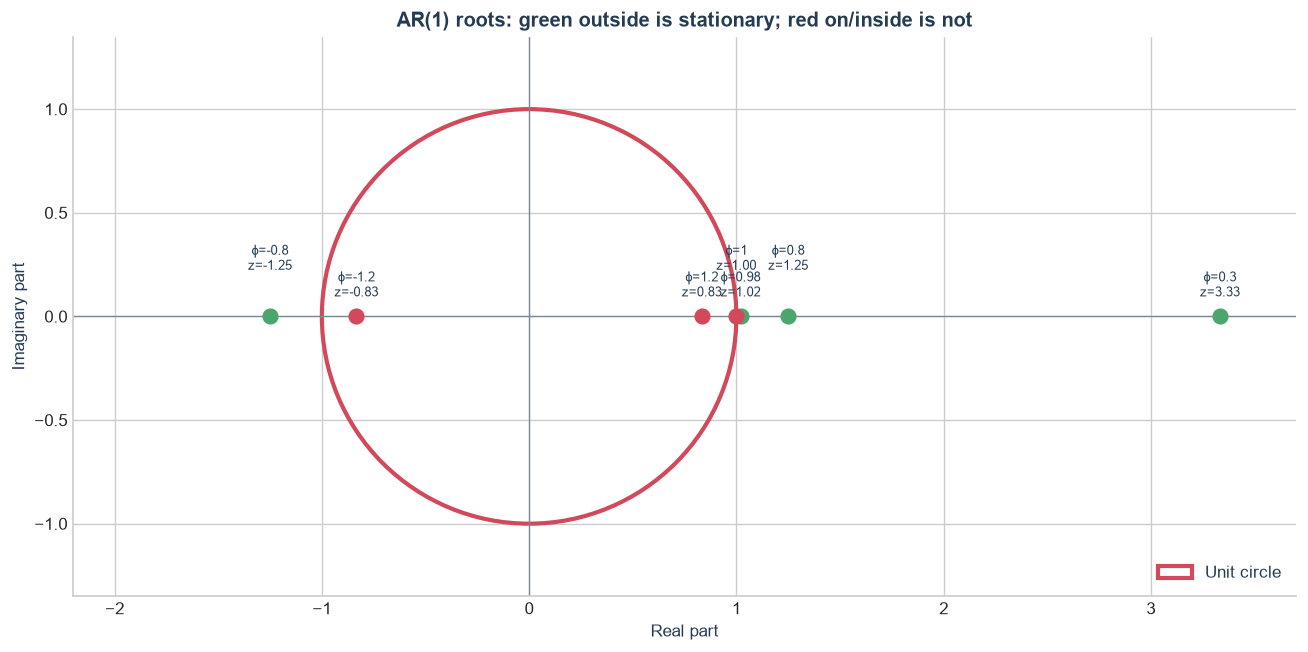

In [7]:
root_phis = [-1.20, -0.80, 0.30, 0.80, 0.98, 1.00, 1.20]
fig, ax = plt.subplots(figsize=(11, 5.5))
ax.add_patch(Circle((0, 0), 1, fill=False, color=COLORS["red"], linewidth=2.5, label="Unit circle"))
for index, phi in enumerate(root_phis):
    root = 1.0 / phi
    stable = abs(root) > 1.0 + 1e-10
    ax.scatter(root, 0, s=75, color=COLORS["green"] if stable else COLORS["red"], zorder=3)
    ax.annotate(f"ϕ={phi:g}\nz={root:.2f}", (root, 0), xytext=(0, 12 + 16 * (index % 2)), textcoords="offset points", ha="center", fontsize=8)
ax.axhline(0, color=COLORS["gray"], linewidth=0.8)
ax.axvline(0, color=COLORS["gray"], linewidth=0.8)
ax.set(xlim=(-2.2, 3.7), ylim=(-1.35, 1.35), aspect="equal", xlabel="Real part", ylabel="Imaginary part", title="AR(1) roots: green outside is stationary; red on/inside is not")
ax.legend(loc="lower right")
fig.tight_layout()
plt.show()

## 4. The intercept is not the long-run mean

For stationary AR(1),

$$
\mu=\frac{c}{1-\phi}.
$$

With $c=2$ and $\phi=0.7$, the process is pulled toward $2/(1-0.7)=6.67$, not toward 2. The intercept is the one-step contribution when previous values are zero.

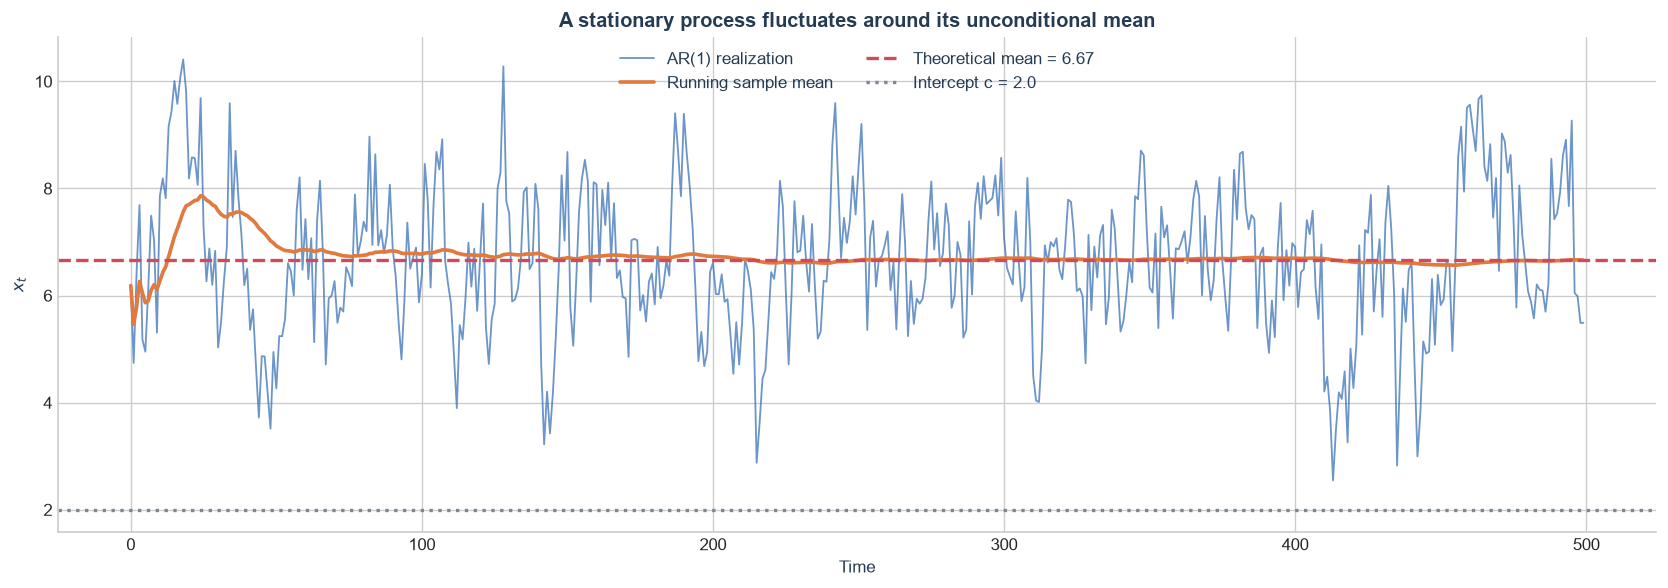

In [8]:
phi, intercept = 0.70, 2.0
mean = unconditional_mean([phi], intercept)
values = simulate_ar([phi], n=500, c=intercept, seed=SEED + 60)
running_mean = np.cumsum(values) / np.arange(1, values.size + 1)

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(values, color=COLORS["blue"], linewidth=1.1, alpha=0.75, label="AR(1) realization")
ax.plot(running_mean, color=COLORS["orange"], linewidth=2.2, label="Running sample mean")
ax.axhline(mean, color=COLORS["red"], linestyle="--", linewidth=2, label=f"Theoretical mean = {mean:.2f}")
ax.axhline(intercept, color=COLORS["gray"], linestyle=":", linewidth=2, label=f"Intercept c = {intercept:.1f}")
ax.set(title="A stationary process fluctuates around its unconditional mean", xlabel="Time", ylabel="$x_t$")
ax.legend(ncol=2)
fig.tight_layout()
plt.show()

## 5. AR(2): persistence and cycles from two lags

$$
x_t=c+\phi_1x_{t-1}+\phi_2x_{t-2}+\varepsilon_t.
$$

For AR(2), checking $|\phi_1|<1$ and $|\phi_2|<1$ separately is **not sufficient**. The roots of

$$1-\phi_1z-\phi_2z^2=0$$

must both be outside the unit circle. Complex-conjugate roots generate damped oscillations; their angle controls the approximate cycle and their modulus controls the damping.

In [9]:
ar2_models = {
    "Persistent": np.array([0.50, 0.20]),
    "Damped cycle": np.array([1.20, -0.70]),
    "Alternating cycle": np.array([-0.65, -0.25]),
    "Unit-root boundary": np.array([1.40, -0.40]),
    "Explosive": np.array([1.30, 0.20]),
}

ar2_table = pl.DataFrame(
    [
        {
            "model": name,
            "phi_1": phi[0],
            "phi_2": phi[1],
            "root_1": f"{ar_roots(phi)[0]:.3f}",
            "root_2": f"{ar_roots(phi)[1]:.3f}",
            "min |root|": np.min(np.abs(ar_roots(phi))),
            "stationary": is_stationary(phi),
        }
        for name, phi in ar2_models.items()
    ]
).with_columns(pl.col("min |root|").round(3))
ar2_table

model,phi_1,phi_2,root_1,root_2,min |root|,stationary
str,f64,f64,str,str,f64,bool
"""Persistent""",0.5,0.2,"""-3.812""","""1.312""",1.312,true
"""Damped cycle""",1.2,-0.7,"""0.857+0.833j""","""0.857-0.833j""",1.195,true
"""Alternating cycle""",-0.65,-0.25,"""-1.300+1.520j""","""-1.300-1.520j""",2.0,true
"""Unit-root boundary""",1.4,-0.4,"""2.500""","""1.000""",1.0,false
"""Explosive""",1.3,0.2,"""-7.195""","""0.695""",0.695,false


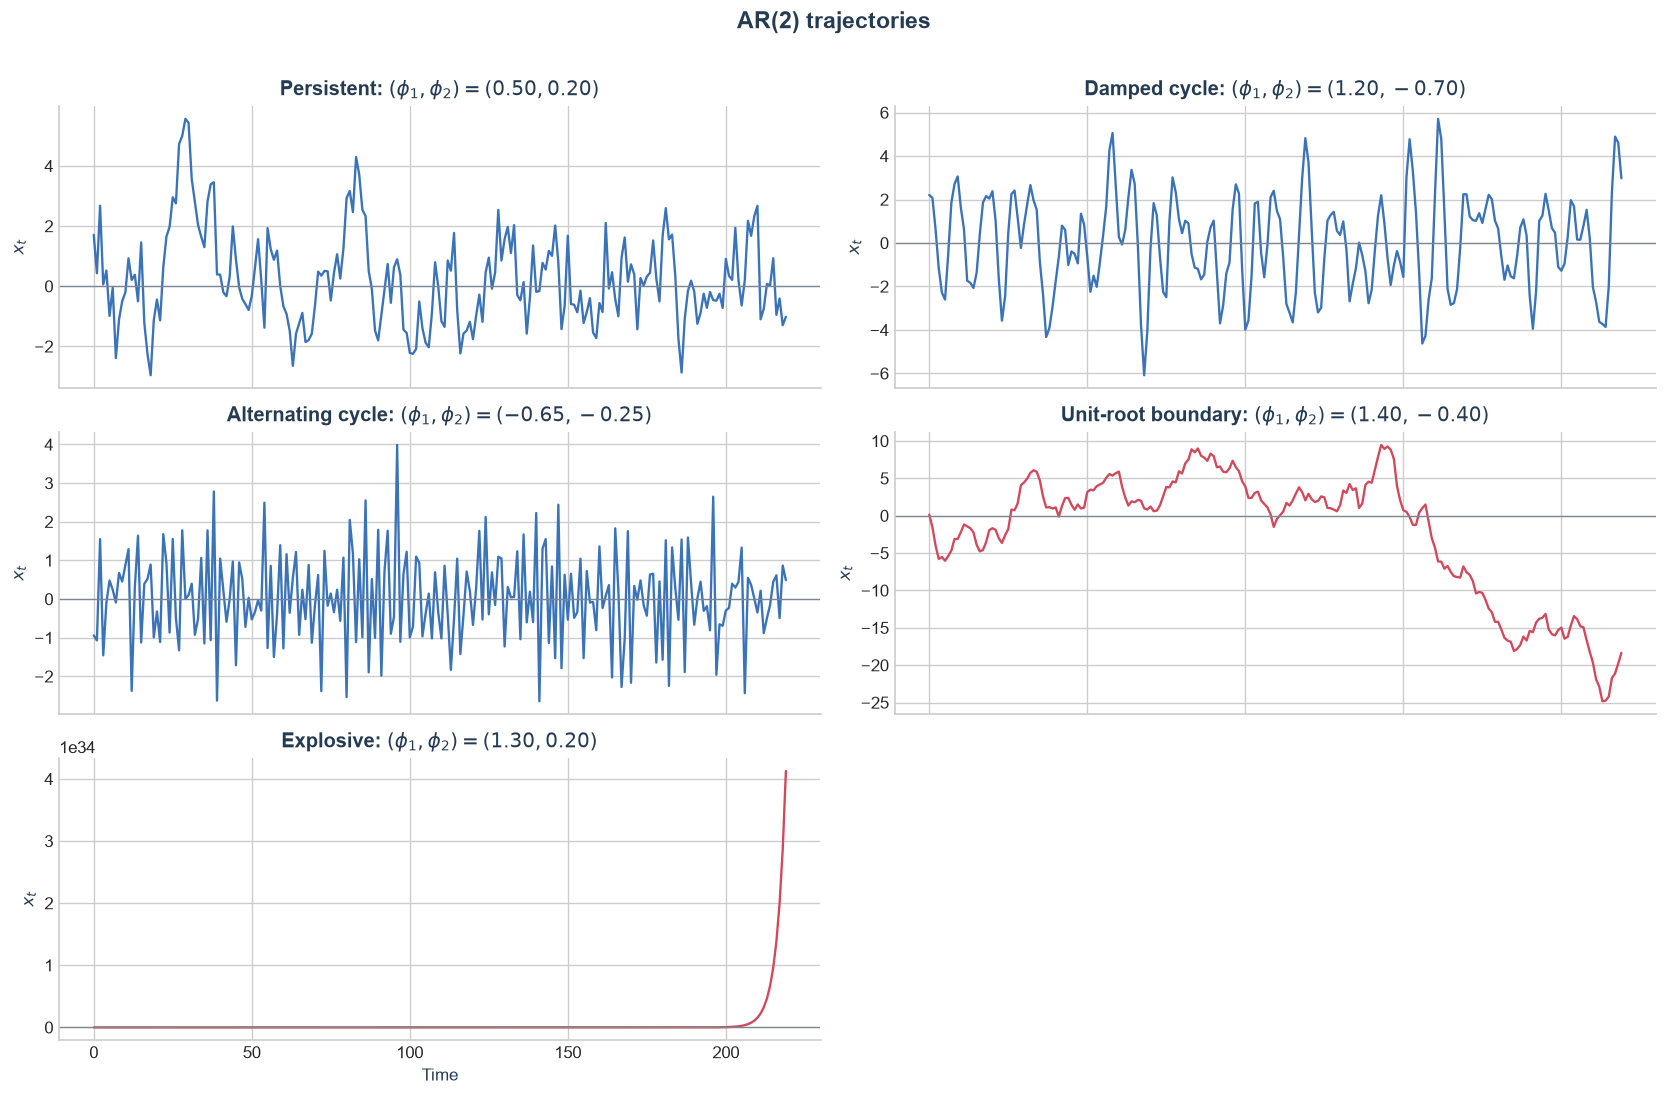

In [10]:
fig, axes = plt.subplots(3, 2, figsize=(14, 9), sharex=True)
for index, (axis, (name, phi)) in enumerate(zip(axes.flat, ar2_models.items())):
    values = simulate_ar(phi, n=220, seed=SEED + 70 + index)
    axis.plot(values, color=COLORS["blue"] if is_stationary(phi) else COLORS["red"], linewidth=1.4)
    axis.axhline(0, color=COLORS["gray"], linewidth=0.8)
    axis.set_title(rf"{name}: $(\phi_1, \phi_2)=({phi[0]:.2f}, {phi[1]:.2f})$")
    axis.set_ylabel("$x_t$")
axes.flat[-1].axis("off")
axes[-1, 0].set_xlabel("Time")
fig.suptitle("AR(2) trajectories", y=1.01, fontsize=14, fontweight="bold")
fig.tight_layout()
plt.show()

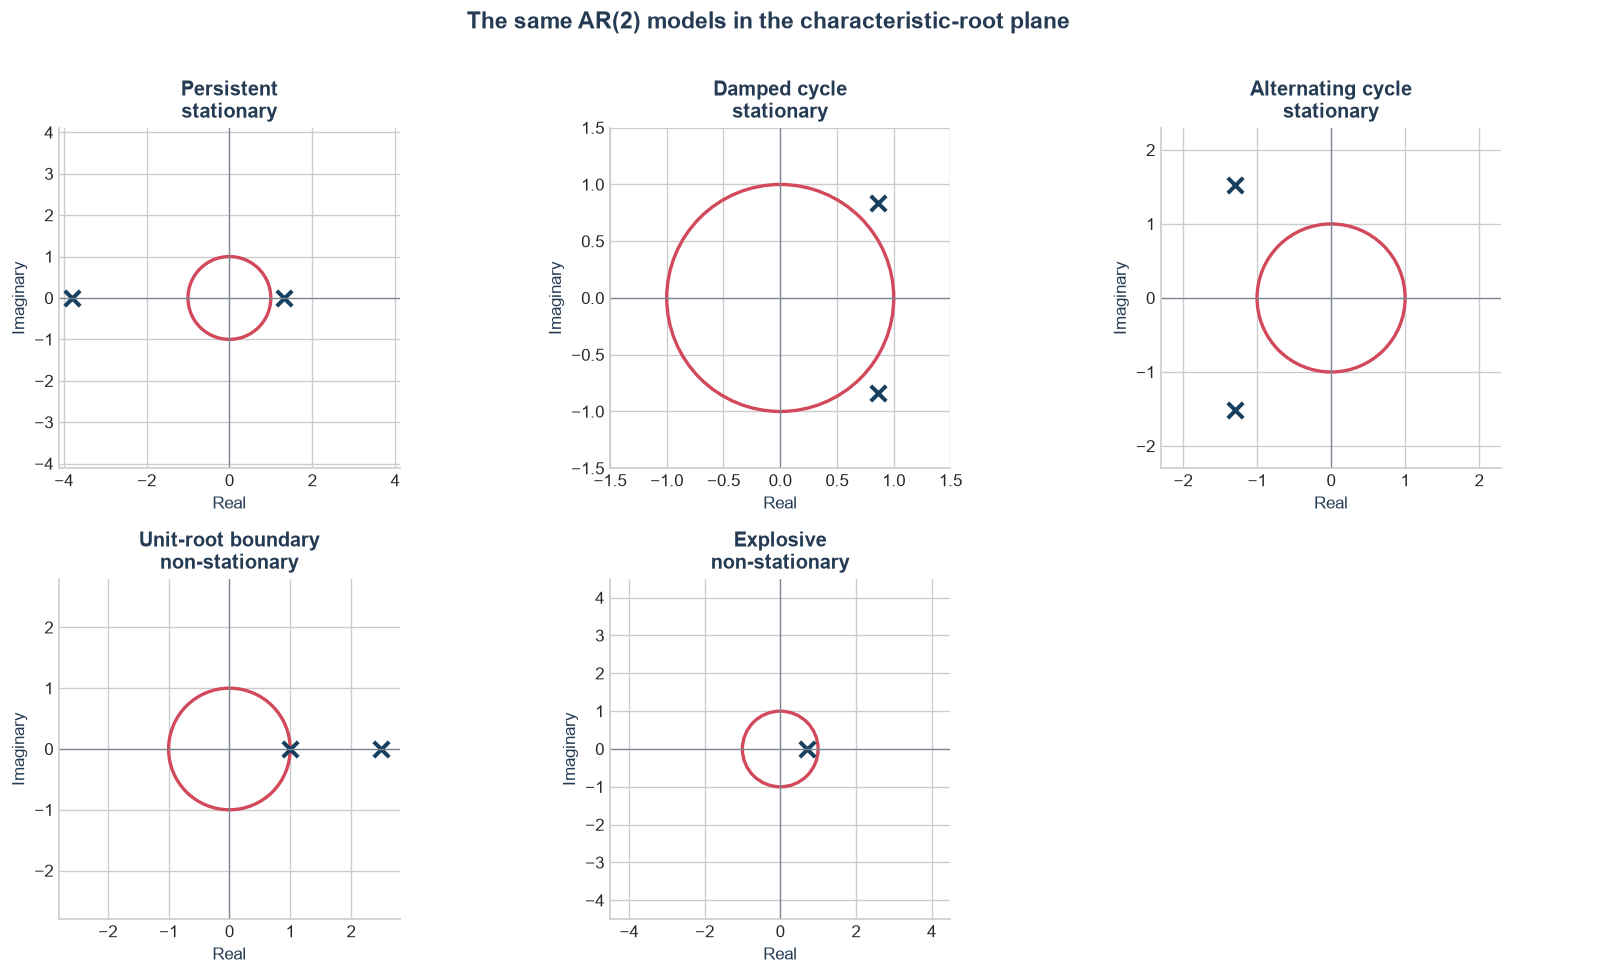

In [11]:
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
for axis, (name, phi) in zip(axes.flat, ar2_models.items()):
    status = "stationary" if is_stationary(phi) else "non-stationary"
    plot_root_plane(axis, phi, f"{name}\n{status}")
axes.flat[-1].axis("off")
fig.suptitle("The same AR(2) models in the characteristic-root plane", y=1.01, fontsize=14, fontweight="bold")
fig.tight_layout()
plt.show()

### The AR(2) stationarity triangle

For AR(2), the root condition is equivalent to three inequalities:

$$
-1<\phi_2<1,\qquad \phi_1+\phi_2<1,\qquad \phi_2-\phi_1<1.
$$

These inequalities form a triangle in coefficient space. A model can have each coefficient between $-1$ and $1$ and still lie outside the stationary region; conversely, a stationary model may have $|\phi_1|>1$, as the damped-cycle example demonstrates.

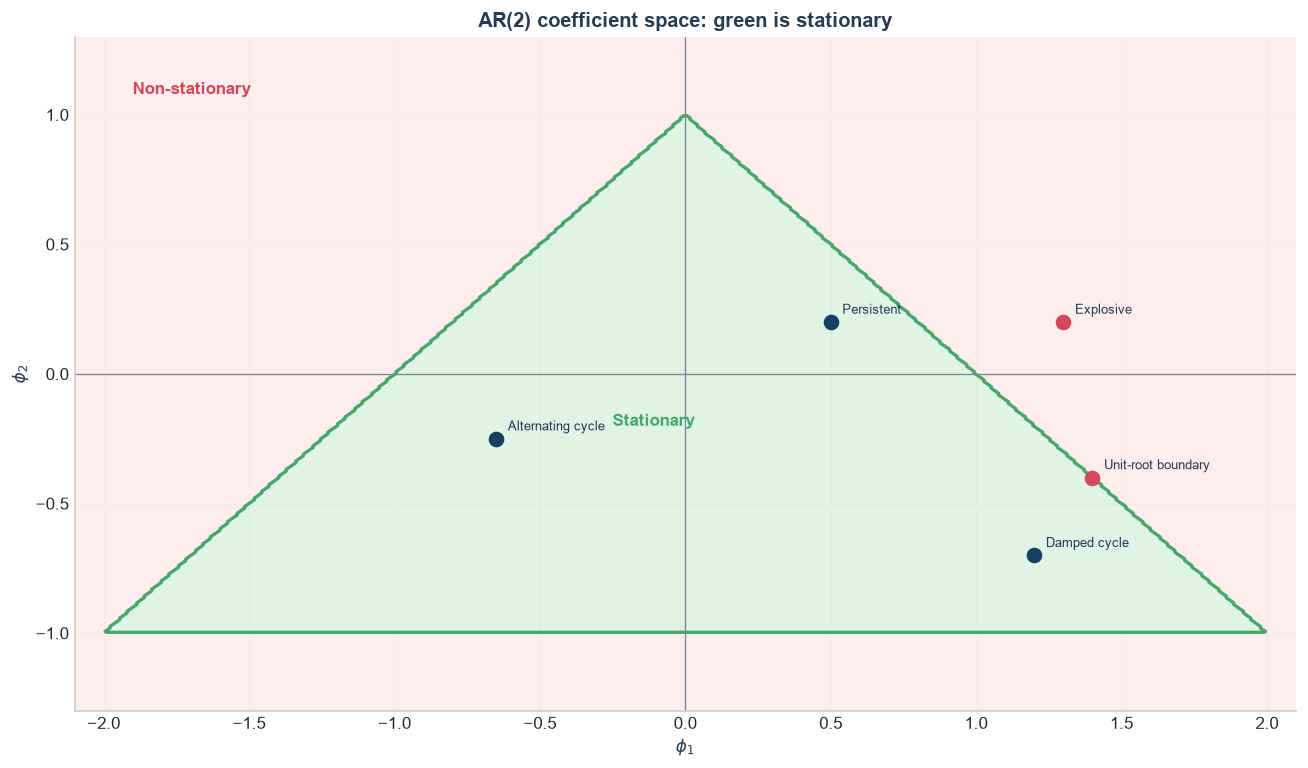

In [12]:
phi1_grid = np.linspace(-2.1, 2.1, 500)
phi2_grid = np.linspace(-1.3, 1.3, 400)
phi1_mesh, phi2_mesh = np.meshgrid(phi1_grid, phi2_grid)
stationary_region = (
    (phi2_mesh > -1)
    & (phi2_mesh < 1)
    & (phi1_mesh + phi2_mesh < 1)
    & (phi2_mesh - phi1_mesh < 1)
)

fig, ax = plt.subplots(figsize=(11, 6.5))
ax.contourf(phi1_mesh, phi2_mesh, stationary_region.astype(int), levels=[-0.5, 0.5, 1.5], colors=["#FDECEC", "#DDF3E4"], alpha=0.9)
ax.contour(phi1_mesh, phi2_mesh, stationary_region.astype(int), levels=[0.5], colors=[COLORS["green"]], linewidths=2)
for name, phi in ar2_models.items():
    ax.scatter(phi[0], phi[1], s=70, color=COLORS["navy"] if is_stationary(phi) else COLORS["red"], zorder=3)
    ax.annotate(name, (phi[0], phi[1]), xytext=(7, 5), textcoords="offset points", fontsize=8)
ax.axhline(0, color=COLORS["gray"], linewidth=0.8)
ax.axvline(0, color=COLORS["gray"], linewidth=0.8)
ax.set(xlabel=r"$\phi_1$", ylabel=r"$\phi_2$", title="AR(2) coefficient space: green is stationary")
ax.text(-1.9, 1.08, "Non-stationary", color=COLORS["red"], fontweight="bold")
ax.text(-0.25, -0.2, "Stationary", color=COLORS["green"], fontweight="bold")
fig.tight_layout()
plt.show()

## 6. Impulse responses: follow one shock through time

Write a stationary AR process as an infinite moving average:

$$
x_t-\mu=\sum_{h=0}^{\infty}\psi_h\varepsilon_{t-h}.
$$

$\psi_h$ is the effect at horizon $h$ of a one-unit innovation today. The recursion is

$$
\psi_0=1,\qquad
\psi_h=\sum_{i=1}^{\min(p,h)}\phi_i\psi_{h-i}.
$$

Stationarity requires these effects to decay. Oscillating decay is allowed; permanent or growing effects are not.

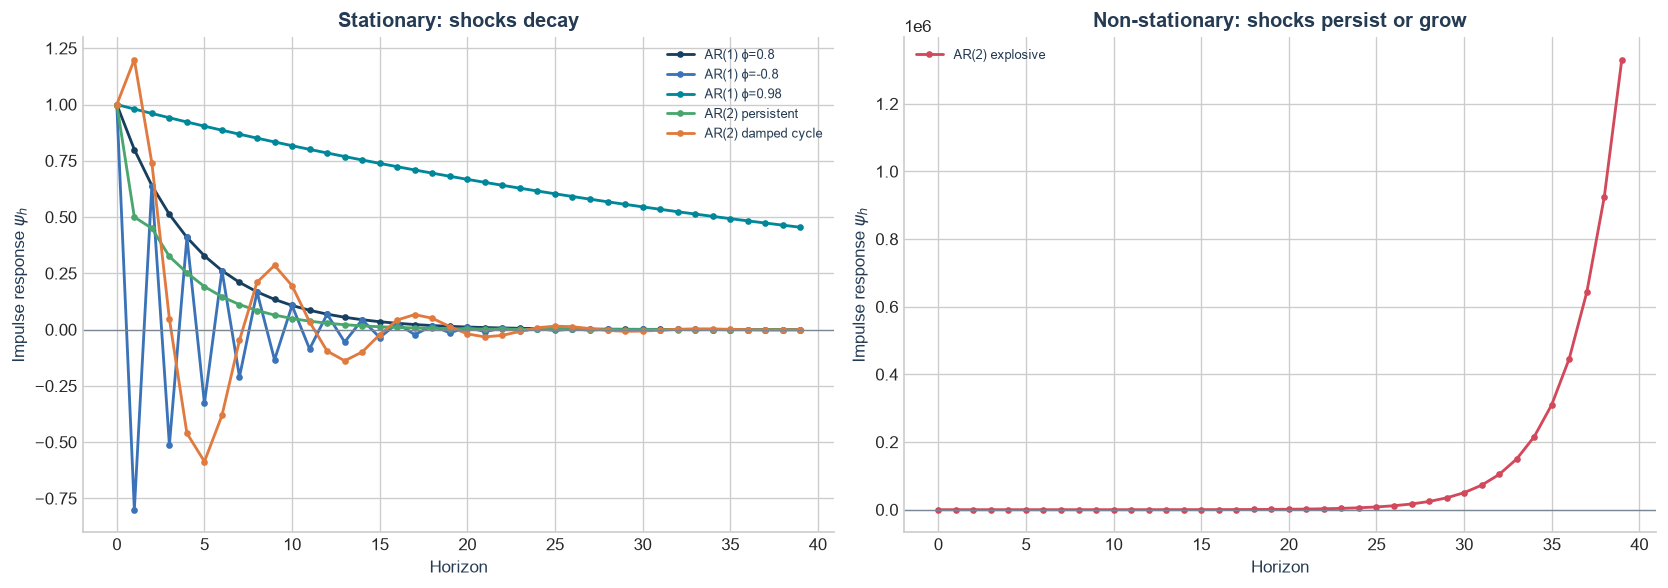

In [13]:
impulse_models = {
    "AR(1) ϕ=0.8": [0.8],
    "AR(1) ϕ=-0.8": [-0.8],
    "AR(1) ϕ=0.98": [0.98],
    "AR(2) persistent": ar2_models["Persistent"],
    "AR(2) damped cycle": ar2_models["Damped cycle"],
    "AR(2) explosive": ar2_models["Explosive"],
}

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharex=True)
for index, (name, phi) in enumerate(impulse_models.items()):
    response = impulse_response(phi, horizon=40)
    axis = axes[0] if is_stationary(phi) else axes[1]
    axis.plot(response, marker="o", markersize=3, linewidth=1.7, label=name, color=list(COLORS.values())[index])
for axis, title in zip(axes, ["Stationary: shocks decay", "Non-stationary: shocks persist or grow"]):
    axis.axhline(0, color=COLORS["gray"], linewidth=0.8)
    axis.set(title=title, xlabel="Horizon", ylabel=r"Impulse response $\psi_h$")
    axis.legend(fontsize=8)
fig.tight_layout()
plt.show()

## 7. AR(3): the same rule, one more lag

Higher order does not change the logic. For

$$
x_t=0.55x_{t-1}-0.25x_{t-2}+0.20x_{t-3}+\varepsilon_t,
$$

we inspect all three roots. The time-domain trajectory alone does not reliably reveal the order; roots, ACF/PACF behavior, and model comparison provide different pieces of evidence.

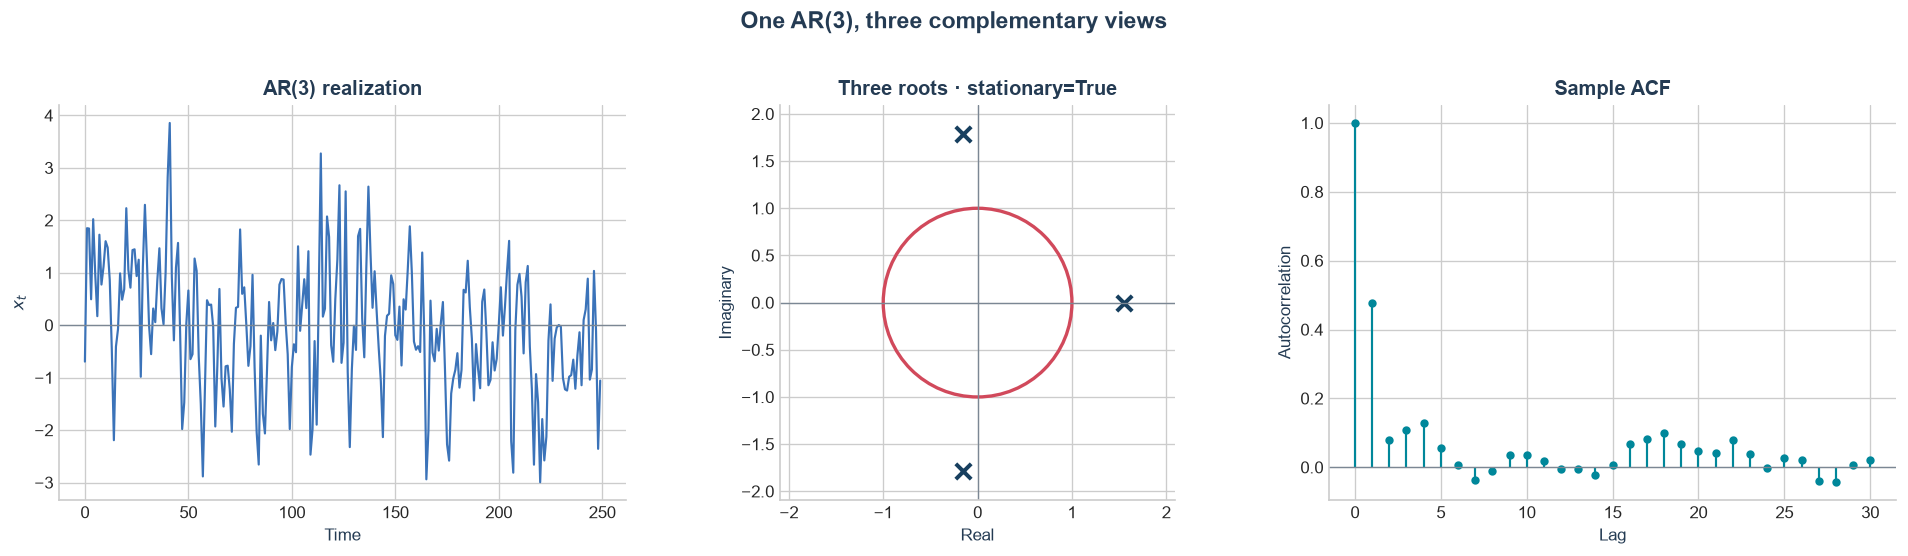

In [14]:
ar3_phi = np.array([0.55, -0.25, 0.20])
ar3_values = simulate_ar(ar3_phi, n=500, seed=SEED + 90)
ar3_acf = acf(ar3_values, nlags=30, fft=True)

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
axes[0].plot(ar3_values[:250], color=COLORS["blue"], linewidth=1.3)
axes[0].axhline(0, color=COLORS["gray"], linewidth=0.8)
axes[0].set(title="AR(3) realization", xlabel="Time", ylabel="$x_t$")

plot_root_plane(axes[1], ar3_phi, f"Three roots · stationary={is_stationary(ar3_phi)}")

lags = np.arange(ar3_acf.size)
markerline, stemlines, _ = axes[2].stem(lags, ar3_acf, linefmt=COLORS["teal"], markerfmt="o", basefmt=" ")
plt.setp(stemlines, linewidth=1.3)
plt.setp(markerline, markersize=4, color=COLORS["teal"])
axes[2].axhline(0, color=COLORS["gray"], linewidth=0.8)
axes[2].set(title="Sample ACF", xlabel="Lag", ylabel="Autocorrelation")

fig.suptitle("One AR(3), three complementary views", y=1.02, fontsize=14, fontweight="bold")
fig.tight_layout()
plt.show()

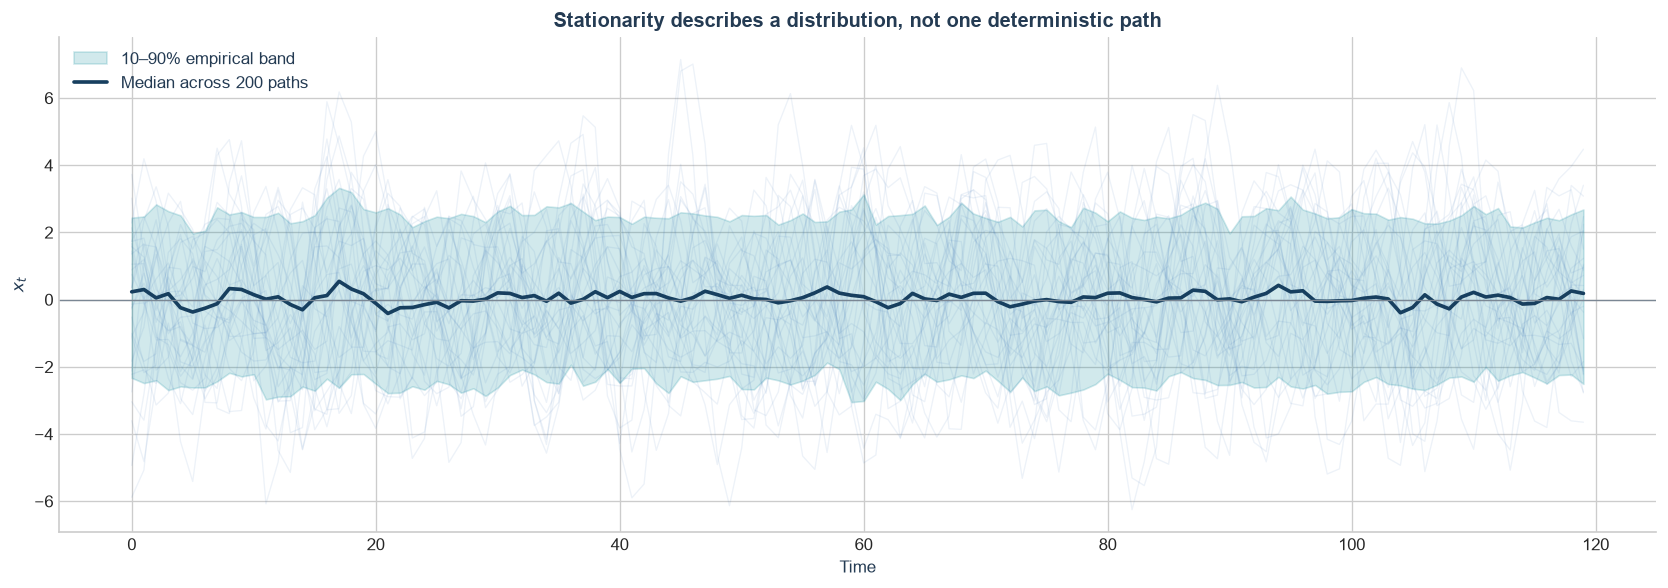

In [15]:
paths = np.vstack(
    [simulate_ar(ar2_models["Damped cycle"], n=120, seed=SEED + 500 + seed) for seed in range(200)]
)
median = np.median(paths, axis=0)
lower, upper = np.quantile(paths, [0.10, 0.90], axis=0)

fig, ax = plt.subplots(figsize=(14, 5))
for path in paths[:30]:
    ax.plot(path, color=COLORS["blue"], alpha=0.09, linewidth=0.8)
ax.fill_between(np.arange(paths.shape[1]), lower, upper, color=COLORS["teal"], alpha=0.18, label="10–90% empirical band")
ax.plot(median, color=COLORS["navy"], linewidth=2.2, label="Median across 200 paths")
ax.axhline(0, color=COLORS["gray"], linewidth=0.8)
ax.set(title="Stationarity describes a distribution, not one deterministic path", xlabel="Time", ylabel="$x_t$")
ax.legend()
fig.tight_layout()
plt.show()

## 8. Compact model audit

The root criterion unifies every example. A minimum root modulus just above one indicates a stationary but highly persistent process; exactly one is a boundary; below one is unstable.

In [16]:
all_models = {
    "AR(1) white noise": np.array([0.0]),
    "AR(1) persistent": np.array([0.8]),
    "AR(1) alternating": np.array([-0.8]),
    "AR(1) near-unit": np.array([0.98]),
    "AR(1) unit root": np.array([1.0]),
    **{f"AR(2) {name.lower()}": phi for name, phi in ar2_models.items()},
    "AR(3) example": ar3_phi,
}

summary_rows = []
for name, phi in all_models.items():
    roots = ar_roots(phi)
    summary_rows.append(
        {
            "model": name,
            "order": len(phi),
            "coefficients": np.array2string(phi, precision=2, separator=", "),
            "min |root|": np.inf if roots.size == 0 else np.min(np.abs(roots)),
            "stationary": is_stationary(phi),
            "sum(phi)": np.sum(phi),
        }
    )

model_audit = pl.DataFrame(summary_rows).with_columns(
    pl.col("min |root|", "sum(phi)").round(3)
)
model_audit

model,order,coefficients,min |root|,stationary,sum(phi)
str,i64,str,f64,bool,f64
"""AR(1) white noise""",1,"""[0.]""",inf,true,0.0
"""AR(1) persistent""",1,"""[0.8]""",1.25,true,0.8
"""AR(1) alternating""",1,"""[-0.8]""",1.25,true,-0.8
"""AR(1) near-unit""",1,"""[0.98]""",1.02,true,0.98
"""AR(1) unit root""",1,"""[1.]""",1.0,false,1.0
…,…,…,…,…,…
"""AR(2) damped cycle""",2,"""[ 1.2, -0.7]""",1.195,true,0.5
"""AR(2) alternating cycle""",2,"""[-0.65, -0.25]""",2.0,true,-0.9
"""AR(2) unit-root boundary""",2,"""[ 1.4, -0.4]""",1.0,false,1.0


## 9. What to remember

1. **Equation:** $x_t=c+\sum_{i=1}^{p}\phi_i x_{t-i}+\varepsilon_t$.
2. **AR(1):** $|\phi|<1$; positive values persist, negative values alternate.
3. **AR($p$):** all roots of $1-\phi_1z-\cdots-\phi_pz^p=0$ must satisfy $|z|>1$.
4. **Mean:** when stationary, $\mu=c/(1-\sum_i\phi_i)$.
5. **Memory:** stationarity means impulse responses eventually decay, not that every realization looks calm.
6. **Near-unit roots:** technically stationary models can be extremely persistent and hard to distinguish from unit-root processes in short samples.
7. **Order:** a trajectory or ACF alone does not prove the true AR order; use PACF, diagnostics, and out-of-sample validation as well.

### Exercises

- Change $\phi$ from 0.90 to 0.99 and measure how many lags are required for $|\phi|^k<0.05$.
- Find an AR(2) with complex roots whose approximate oscillation period is six observations.
- Move each marked AR(2) point across a boundary of the stationarity triangle and compare its impulse response.
- Set $c\neq0$ in an AR(2), compute the theoretical mean, and verify it over many simulations.